<a href="https://colab.research.google.com/github/adrianguerardi2006/Disciplina-De-Inteligencia-Artificial/blob/main/Notebook_FishMorph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Importando as bibliotecas

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


#2. Carregando o dataset

In [2]:
df = pd.read_csv('FISHMORPH_Family_Dataset.csv')
df.head()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Family
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cyprinidae
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Cichlidae
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cyprinidae
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cyprinidae
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cyprinidae


#3. Verificação dos dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Family  8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB


In [4]:
df.describe()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt
count,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000
mean,22.004517,4.452438,0.549087,0.391665,0.381768,0.399786,0.571818,0.285316,0.189343,2.560795
std,33.612007,2.338235,0.094883,0.132814,0.194352,0.302658,0.117486,0.155629,0.056109,1.016659
min,1.200000,1.033084,0.159248,0.000000,0.000000,0.000000,0.224525,0.000000,0.000000,0.000000
25%,7.000000,3.139102,0.487993,0.293205,0.278014,0.257999,0.490052,0.193134,0.157972,1.999744
50%,12.600000,4.038851,0.546213,0.389429,0.406904,0.361436,0.564739,0.275039,0.183497,2.436329
75%,24.500000,5.002621,0.605125,0.486221,0.516001,0.490671,0.648039,0.368876,0.215031,2.919818
max,800.000000,43.728161,1.000000,1.026667,1.026316,7.060344,1.230105,0.857097,0.511113,15.452061


In [5]:
df.isnull().sum()

,0
MBl,0
BEl,0
VEp,0
REs,0
OGp,0
RMl,0
BLs,0
PFv,0
PFs,0
CPt,0


In [6]:
df.duplicated().sum()

np.int64(1)

4. Verficação das classes

In [7]:
contagem = df['Family'].value_counts()

print('Famílias com apenas 1 registro:', (contagem == 1).sum())
print('Famílias com 2 ou mais registros:', (contagem >= 2).sum())

familias_validas = contagem[contagem >= 2].index
df = df[df['Family'].isin(familias_validas)].copy()

print('\nTotal de famílias utilizadas:', df['Family'].nunique())
print('Total de registros utilizados:', len(df))

Famílias com apenas 1 registro: 35
Famílias com 2 ou mais registros: 162

Total de famílias utilizadas: 162
Total de registros utilizados: 8307


#5. Divisão de treino e teste

In [8]:
X = df.drop('Family', axis=1)
y = df['Family']

print('Características utilizadas:')
print(X.columns.tolist())

print('\nVariável alvo: Family')

Características utilizadas:
['MBl', 'BEl', 'VEp', 'REs', 'OGp', 'RMl', 'BLs', 'PFv', 'PFs', 'CPt']

Variável alvo: Family


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (6645, 10)
Teste: (1662, 10)


#6. Pipeline do SVM

In [10]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

#7. Gridserach

In [11]:
param_grid = {
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1]
}

cv = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


#8. Treinamento do modelo

In [12]:
grid.fit(X_train, y_train)

Fitting 2 folds for each of 27 candidates, totalling 54 fits


GridSearchCV(cv=StratifiedKFold(n_splits=2, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10],
                         'svm__gamma': ['scale', 0.01, 0.1],
                         'svm__kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy', verbose=1)

#9. Melhores parâmetros encontrados

In [13]:
print('Melhores parâmetros:')
print(grid.best_params_)

print('\nMelhor acurácia na Cross Validation:')
print(grid.best_score_)

Melhores parâmetros:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Melhor acurácia na Cross Validation:
0.6401801031723326


#10. Conjunto de teste

In [14]:
y_pred = grid.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print('Acurácia no conjunto de teste:', accuracy)

print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred, zero_division=0))

Acurácia no conjunto de teste: 0.6696750902527075

Relatório de classificação:
                   precision    recall  f1-score   support

   Abyssocottidae       0.25      0.25      0.25         4
Acestrorhynchidae       0.75      1.00      0.86         3
        Achiridae       0.00      0.00      0.00         2
    Acipenseridae       0.75      0.75      0.75         4
 Adrianichthyidae       0.50      1.00      0.67         1
         Akysidae       0.33      0.33      0.33         3
        Alestidae       0.00      0.00      0.00        15
       Ambassidae       0.80      0.80      0.80         5
   Amblycipitidae       0.00      0.00      0.00         3
     Amblyopsidae       0.00      0.00      0.00         0
      Amphiliidae       0.75      0.38      0.50         8
      Anabantidae       1.00      0.25      0.40         4
      Anablepidae       0.00      0.00      0.00         2
      Anguillidae       1.00      1.00      1.00         2
      Anostomidae       0.50      0

#11. Matrizes de confusão

<Figure size 1200x1000 with 0 Axes>

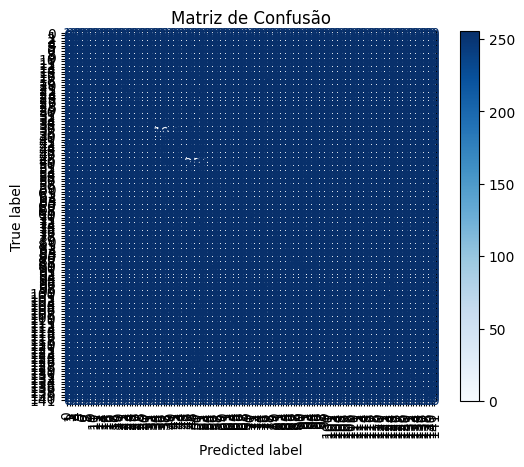

In [15]:
y_pred = grid.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap='Blues',
    xticks_rotation=90
)

plt.title("Matriz de Confusão")
plt.show()

<Figure size 1000x800 with 0 Axes>

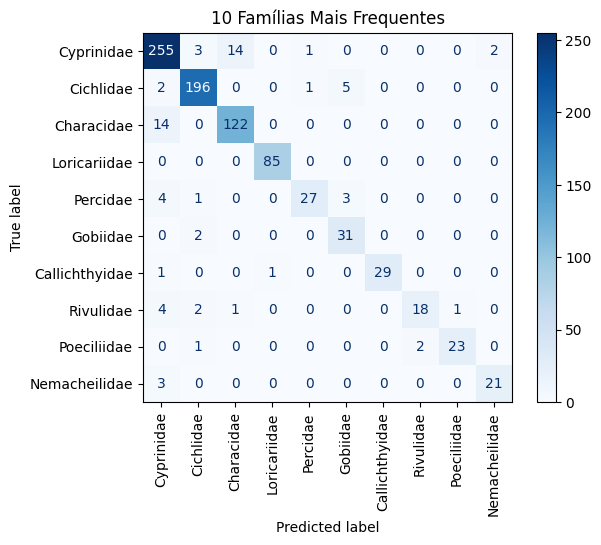

In [16]:
top10 = df['Family'].value_counts().head(10).index

mask = y_test.isin(top10)

y_test_top = y_test[mask]
y_pred_top = pd.Series(y_pred, index=y_test.index)[mask]

cm_top = confusion_matrix(
    y_test_top,
    y_pred_top,
    labels=top10
)

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_top,
    display_labels=top10
)

disp.plot(
    cmap='Blues',
    xticks_rotation=90
)

plt.title("10 Famílias Mais Frequentes")
plt.show()

#12. Conclusão

O modelo SVM classifica os grupos de peixes com base em suas características morfológicas, o dataset possui originalmente 197 famílias, após retirar famílias com apenas um registro, o modelo trabalha com 162 famílias. Entre as famílias com maior quantidade de registros estão Cyprinidae, Cichlidae, Characidae, Loricariidae e Percidae.

Assim, o modelo busca identificar a família à qual cada exemplar pertence, utilizando as características disponíveis no dataset.